In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df = sns.load_dataset("mpg")
df = df.dropna(subset=['horsepower']) # bağımsız değişkene ait null gözlemleri veri setinden çıkaralım.
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


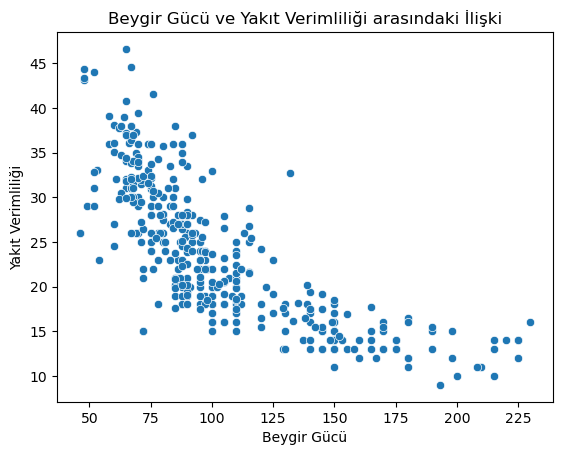

In [6]:
sns.scatterplot(df, x='horsepower', y='mpg')
plt.xlabel('Beygir Gücü')
plt.ylabel('Yakıt Verimliliği')
plt.title('Beygir Gücü ve Yakıt Verimliliği arasındaki İlişki')
plt.show()

In [8]:
# Polinomal Regresyon'da bağımsız değişkeni x fit etmek, verideki eğrileri yakalamak için düz bir çizgiyi bükerek esnek bir eğriye dönüştürmektir
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
X = df[['horsepower']]
y = df['mpg']
poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)
model_poly = LinearRegression()
model_poly.fit(X_train, y_train)
y_pred_poly = model_poly.predict(X_test)
r2_poly = r2_score(y_test, y_pred_poly)
print(f"R² (Polynomial, degree=2): {r2_poly:.4f}")

R² (Polynomial, degree=2): 0.6383


### Derece Karşılaştırması ve Overfitting Gözlemi
Degree 1: R²=%56.6, Degree 2: R²=%63.92, Degree 3: R²=%63.83

Degree 1'den 2'ye geçişte R² belirgin şekilde arttı bu, verideki gerçek eğriselliği yakaladığımızı gösteriyor (bias azaldı). Ama Degree 2'den 3'e geçişte R² artmadı, hafifçe düştü bu, modelin artık gerçek örüntüyü değil, eğitim verisindeki gürültüyü ezberlemeye başladığının (overfitting/variance artışı) bir işareti. Bu veri seti için Degree=2, bias-variance dengesinin en iyi olduğu nokta gibi görünüyor.